In [2]:
#Heart Disease Prediction Project
#Data Manipulation libraries
import numpy as np
import pandas as pd

# Data visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# loading dataset
# source:kaggle
data=pd.read_csv('C:/Users/abbas/Downloads/heart_disease_dataset.csv')
df=pd.DataFrame(data)

# dataset basic information
print('shape of dataset:')
print(df.shape)
print('columns name:')
print(df.columns.to_list())
print('basic statistics:')
print(df.describe())


shape of dataset:
(1000, 16)
columns name:
['Age', 'Gender', 'Cholesterol', 'Blood Pressure', 'Heart Rate', 'Smoking', 'Alcohol Intake', 'Exercise Hours', 'Family History', 'Diabetes', 'Obesity', 'Stress Level', 'Blood Sugar', 'Exercise Induced Angina', 'Chest Pain Type', 'Heart Disease']
basic statistics:
               Age  Cholesterol  Blood Pressure   Heart Rate  Exercise Hours  \
count  1000.000000  1000.000000       1000.0000  1000.000000     1000.000000   
mean     52.293000   249.939000        135.2810    79.204000        4.529000   
std      15.727126    57.914673         26.3883    11.486092        2.934241   
min      25.000000   150.000000         90.0000    60.000000        0.000000   
25%      39.000000   200.000000        112.7500    70.000000        2.000000   
50%      52.000000   248.000000        136.0000    79.000000        4.500000   
75%      66.000000   299.000000        159.0000    89.000000        7.000000   
max      79.000000   349.000000        179.0000    9

In [3]:
print(df.dtypes)

Age                        int64
Gender                       str
Cholesterol                int64
Blood Pressure             int64
Heart Rate                 int64
Smoking                      str
Alcohol Intake               str
Exercise Hours             int64
Family History               str
Diabetes                     str
Obesity                      str
Stress Level               int64
Blood Sugar                int64
Exercise Induced Angina      str
Chest Pain Type              str
Heart Disease              int64
dtype: object


In [4]:
# checking missing values
print('Missing values in each collumn:')
print(df.isnull().sum())
print('Missing values percentage:')
print(df.isnull().sum()/len(df))

Missing values in each collumn:
Age                          0
Gender                       0
Cholesterol                  0
Blood Pressure               0
Heart Rate                   0
Smoking                      0
Alcohol Intake             340
Exercise Hours               0
Family History               0
Diabetes                     0
Obesity                      0
Stress Level                 0
Blood Sugar                  0
Exercise Induced Angina      0
Chest Pain Type              0
Heart Disease                0
dtype: int64
Missing values percentage:
Age                        0.00
Gender                     0.00
Cholesterol                0.00
Blood Pressure             0.00
Heart Rate                 0.00
Smoking                    0.00
Alcohol Intake             0.34
Exercise Hours             0.00
Family History             0.00
Diabetes                   0.00
Obesity                    0.00
Stress Level               0.00
Blood Sugar                0.00
Exercise Induced

In [5]:
# checking unique values in Alcohol Intake Column
print(df['Alcohol Intake'].unique())


<StringArray>
['Heavy', nan, 'Moderate']
Length: 3, dtype: str


In [6]:
# checking mode of Alcohol Intake column
print('Mode of Alcohol intake:')
print(df['Alcohol Intake'].mode()[0])

Mode of Alcohol intake:
Heavy


In [7]:
# fill missing values with mode of Alcohol Intake column
df['Alcohol Intake']=df['Alcohol Intake'].fillna(df['Alcohol Intake'].mode()[0])
print('After filling missing values:')
print(df['Alcohol Intake'].isnull().sum())

After filling missing values:
0


In [8]:
# checking there is any other missing values in dataframe
print(df.isnull().sum())

Age                        0
Gender                     0
Cholesterol                0
Blood Pressure             0
Heart Rate                 0
Smoking                    0
Alcohol Intake             0
Exercise Hours             0
Family History             0
Diabetes                   0
Obesity                    0
Stress Level               0
Blood Sugar                0
Exercise Induced Angina    0
Chest Pain Type            0
Heart Disease              0
dtype: int64


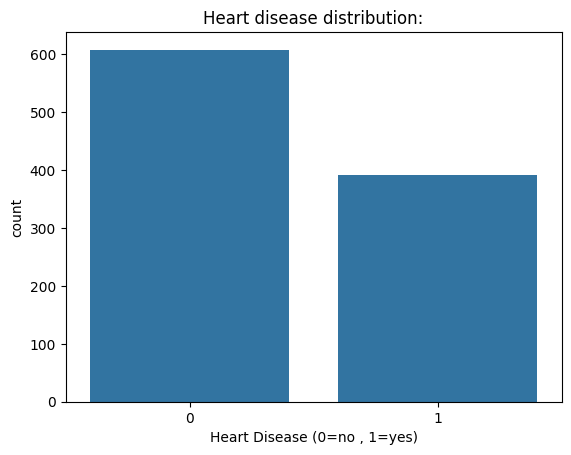

In [9]:
# Data Visualization
# Heart disease distribution
plt.Figure(figsize=(6,4))
sns.countplot(x='Heart Disease',data=df)
plt.title('Heart disease distribution:')
plt.xlabel('Heart Disease (0=no , 1=yes)')
plt.ylabel('count')
plt.show()

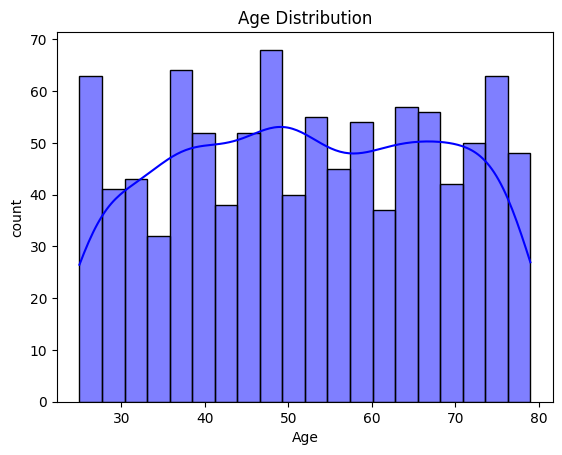

In [10]:
# Age distribution
plt.Figure(figsize=(6,4))
sns.histplot(df['Age'],bins=20,kde=True,color='blue')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('count')
plt.show()

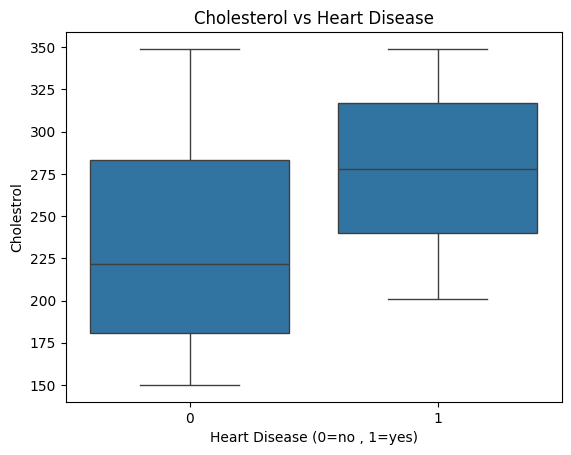

In [11]:
# Cholesterol vs Heart Disease Boxplot
plt.Figure(figsize=(8,5))
sns.boxplot(x='Heart Disease',y='Cholesterol',data=df)
plt.title('Cholesterol vs Heart Disease')
plt.xlabel('Heart Disease (0=no , 1=yes)')
plt.ylabel('Cholestrol')
plt.show()

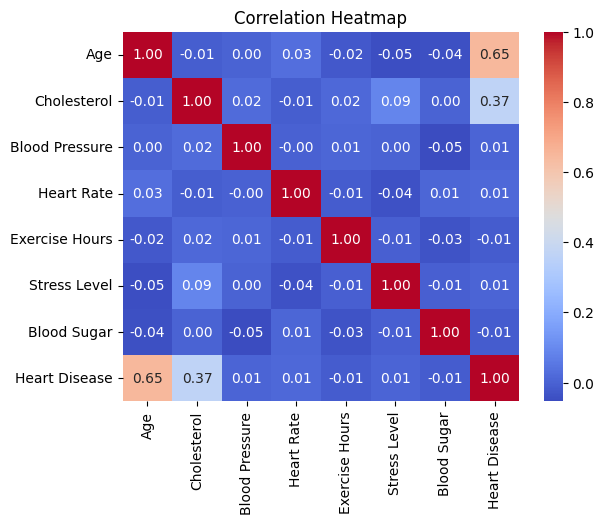

In [12]:
# Correlation Heatmap
plt.Figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True),annot=True,fmt='.2f',cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

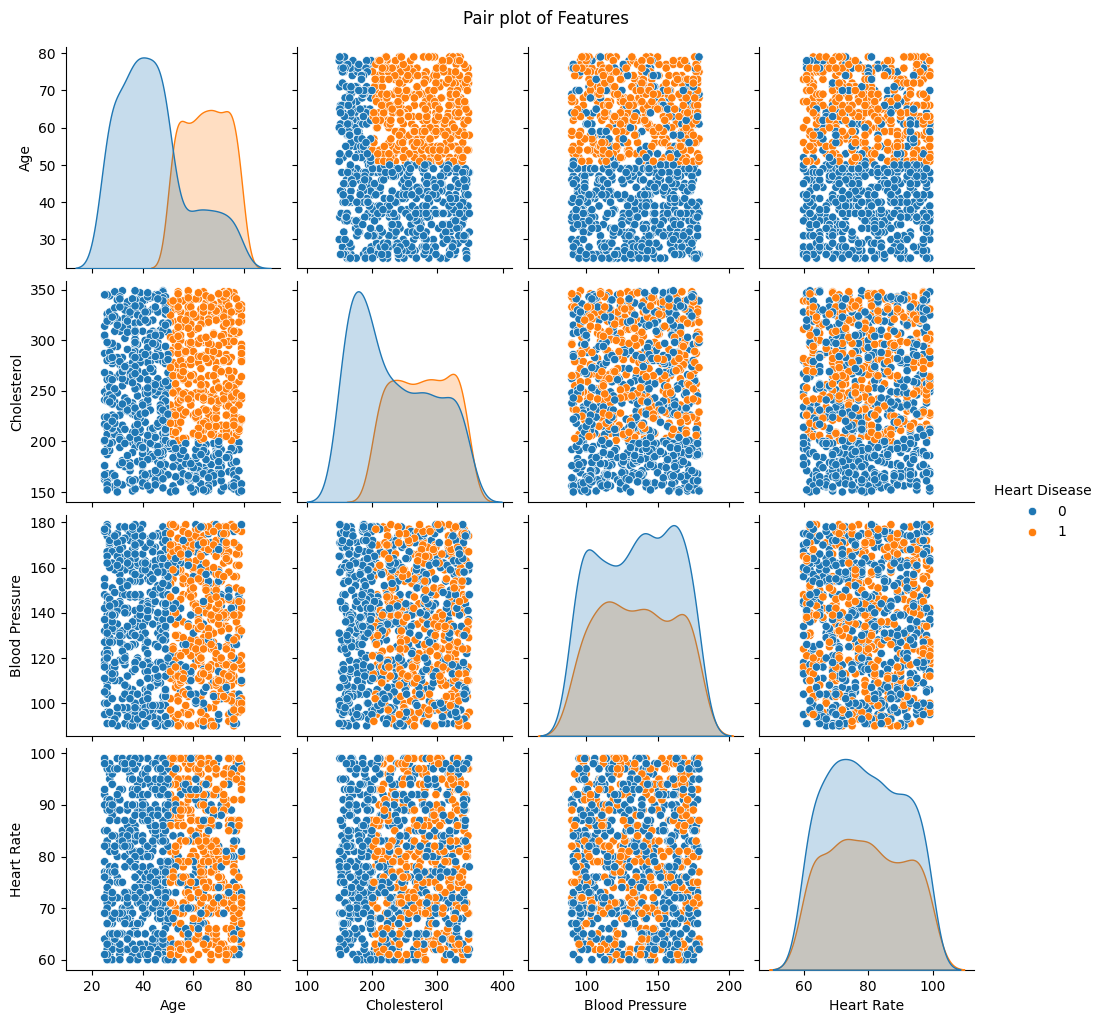

In [13]:
# Pair plot of features
sns.pairplot(df[['Age','Cholesterol','Blood Pressure','Heart Rate','Heart Disease']],hue='Heart Disease')
plt.suptitle('Pair plot of Features',y=1.02)
plt.show()

In [14]:
from sklearn.model_selection import train_test_split
x=df[['Age']] # input variable
y=df['Heart Disease'] # output variable
# Dividing data into 80% training and 20% testing
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print('total data:',len(x))
print('Training data:',len(x_train))
print('Testing data:',len(x_test))



total data: 1000
Training data: 800
Testing data: 200


In [15]:
# Model fit
from sklearn.linear_model import LinearRegression
# simple linear regression model
model=LinearRegression()
# Training model on training data
model.fit(x_train,y_train)
print('model successfully trained:')
# Model formua values
print('slope(m):',model.coef_)
print('intercept(b):',model.intercept_)

model successfully trained:
slope(m): [0.020021]
intercept(b): -0.6597483785006524


In [16]:
# make predition on training data
y_pred=model.predict(x_test)
# first 10 predicted vs actual values
print('predicted values:')
print(y_pred[0:10])
print('actual values:')
print(y_test.values[0:10])

predicted values:
[0.88186851 0.18113356 0.18113356 0.14109156 0.9018895  0.14109156
 0.32128055 0.20115456 0.58155353 0.62159552]
actual values:
[1 0 0 0 1 0 0 0 1 0]


In [17]:
# Model Evaluation
from sklearn.metrics import mean_squared_error,r2_score
# checking model acuracy
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
print('mean squared error:',mse)
print('R2 score:',r2)

mean squared error: 0.1358558328799887
R2 score: 0.4383801865234035


In [18]:
# new patient prediction
new_patient=pd.DataFrame([[65]],columns=['Age'])
prediction=model.predict(new_patient)
print('predction:',prediction[0])
if prediction[0]>=0.5:
    print('Risk of Heart Disease.')
else:
    print('No Heaart Disease risk.')

predction: 0.6416165233306799
Risk of Heart Disease.


Part: 2
Multiple Linear Regression

In [19]:
x_multiple=df[['Age','Cholesterol']]
y=df['Heart Disease']

In [20]:
# Train test split
x_train_m,x_test_m,y_train_m,y_test_m=train_test_split(x_multiple,y,test_size=0.2,random_state=42)
print('Training data:',x_train_m.shape)
print('Testing Data:',x_test_m.shape)

Training data: (800, 2)
Testing Data: (200, 2)


In [21]:
# Model Training
model_multi=LinearRegression()
model_multi.fit(x_train_m,y_train_m)
print('Model successfully Trained:')
print('Coeficients:',model_multi.coef_)
print('Intercept:',model_multi.intercept_)

Model successfully Trained:
Coeficients: [0.0202664 0.003123 ]
Intercept: -1.4534878496794008


In [22]:
y_pred_multi=model_multi.predict(x_test_m)
# first 10 predicted vs actual values
print('predicted values:')
print(y_pred_multi[0:10])
print('actual values:')
print(y_test_m.values[0:10])

predicted values:
[ 0.88152974  0.31274106  0.04103968  0.25659324  0.79249099 -0.05570719
  0.20788849  0.30802342  0.51819671  0.45254736]
actual values:
[1 0 0 0 1 0 0 0 1 0]


In [23]:
# checking model acuracy
mse=mean_squared_error(y_test_m,y_pred_multi)
r2=r2_score(y_test_m,y_pred_multi)
print('mean squared error:',mse)
print('R2 score:',r2)

mean squared error: 0.10181220888393558
R2 score: 0.5791144734024987


In [24]:
# new patient prediction
new_patient_multi=pd.DataFrame([[55,280]],columns=['Age','Cholesterol'])
prediction_m=model_multi.predict(new_patient_multi)
print('predction:',prediction_m[0])
if prediction_m[0]>=0.5:
    print('Risk of Heart Disease.')
else:
    print('No Heaart Disease risk.')

predction: 0.5356051545078151
Risk of Heart Disease.


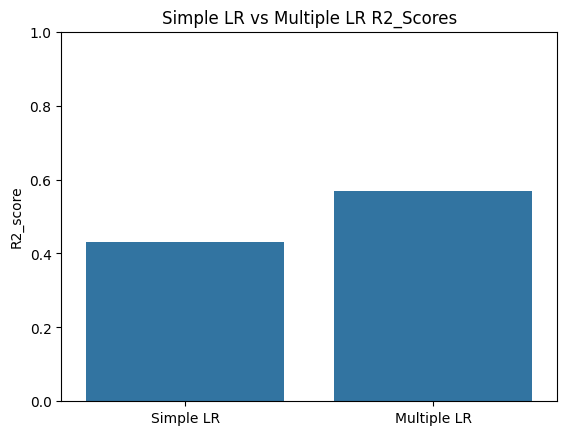

In [25]:
# simple linear regression vs multiple linear regression comparison
model=['Simple LR','Multiple LR']
r2_scores=[0.43,0.57]
plt.Figure(figsize=(8,5))
sns.barplot(x=model,y=r2_scores)
plt.title('Simple LR vs Multiple LR R2_Scores')
plt.ylabel('R2_score')
plt.ylim(0,1)
plt.show()

Part: 3.1 Logistic Regression --> categorical output (0 , 1)

In [26]:
x_lg=df[['Age','Cholesterol']] # input variables
y_lg=df['Heart Disease']   #output variable
# Splitting Data into training and testing
x_train_lg,x_test_lg,y_train_lg,y_test_lg=train_test_split(x_lg,y_lg,test_size=0.2,random_state=2)
print('Total Data:',len(x_lg))
print('Training Data:',len(x_train_lg))
print('Testing Data:',len(x_test_lg))


Total Data: 1000
Training Data: 800
Testing Data: 200


In [27]:
# Import logistic regression model 
from sklearn.linear_model import LogisticRegression
model_lg=LogisticRegression()
# Training model 
model_lg.fit(x_train_lg,y_train_lg)
print('Model successfully trained.')
print('Coefficient:',model_lg.coef_)
print('Intercept:',model_lg.intercept_)

Model successfully trained.
Coefficient: [[0.20948533 0.03728595]]
Intercept: [-21.54448904]


In [28]:
# Predicting on testing data
y_pred_lg=model_lg.predict(x_test_lg)
#  Comparison of actual and predicted values
print('Actual values:',y_test_lg.values[0:20])
print('predicted values:',y_pred_lg[0:20])

Actual values: [1 0 0 0 0 1 0 1 0 0 0 0 0 1 0 0 0 0 1 0]
predicted values: [1 0 0 0 0 1 0 1 0 0 0 0 0 1 0 0 0 0 1 0]


In [29]:
# Evaluation Metrics
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
print('Accuracy:',accuracy_score(y_test_lg,y_pred_lg))
print('Precision:',precision_score(y_test_lg,y_pred_lg))
print('Recall:',recall_score(y_test_lg,y_pred_lg))
print('F1 score:',f1_score(y_test_lg,y_pred_lg))

Accuracy: 0.875
Precision: 0.8513513513513513
Recall: 0.8181818181818182
F1 score: 0.8344370860927153


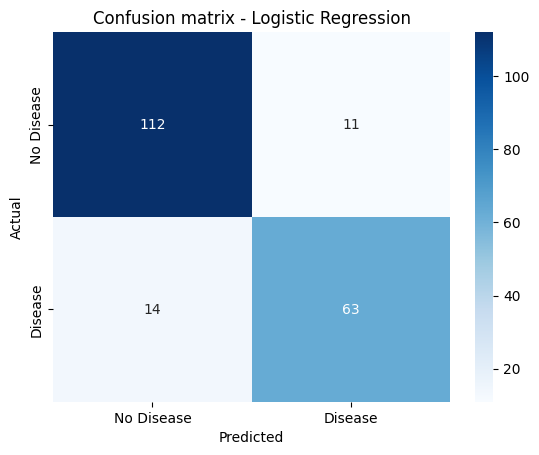

In [30]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test_lg,y_pred_lg)
plt.Figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=['No Disease','Disease'],yticklabels=['No Disease','Disease'])
plt.title('Confusion matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

part 3.2: Logistic Regression After Column Encoding

In [31]:
print(df.dtypes)

Age                        int64
Gender                       str
Cholesterol                int64
Blood Pressure             int64
Heart Rate                 int64
Smoking                      str
Alcohol Intake               str
Exercise Hours             int64
Family History               str
Diabetes                     str
Obesity                      str
Stress Level               int64
Blood Sugar                int64
Exercise Induced Angina      str
Chest Pain Type              str
Heart Disease              int64
dtype: object


In [32]:
# Applying logistic regression after encoding categorical columns
bin_cols=['Gender', 'Alcohol Intake', 'Family History', 'Diabetes', 'Obesity', 'Exercise Induced Angina']
for col in bin_cols:
    print(col)
    print(df[col].unique())


Gender
<StringArray>
['Female', 'Male']
Length: 2, dtype: str
Alcohol Intake
<StringArray>
['Heavy', 'Moderate']
Length: 2, dtype: str
Family History
<StringArray>
['No', 'Yes']
Length: 2, dtype: str
Diabetes
<StringArray>
['No', 'Yes']
Length: 2, dtype: str
Obesity
<StringArray>
['Yes', 'No']
Length: 2, dtype: str
Exercise Induced Angina
<StringArray>
['Yes', 'No']
Length: 2, dtype: str


In [33]:
# converting binary categorical columns to numeric columns using label encoder
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for col in bin_cols:
    df[col]=le.fit_transform(df[col])
print(df.head())


   Age  Gender  Cholesterol  Blood Pressure  Heart Rate  Smoking  \
0   75       0          228             119          66  Current   
1   48       1          204             165          62  Current   
2   53       1          234              91          67    Never   
3   69       0          192              90          72  Current   
4   62       0          172             163          93    Never   

   Alcohol Intake  Exercise Hours  Family History  Diabetes  Obesity  \
0               0               1               0         0        1   
1               0               5               0         0        0   
2               0               3               1         0        1   
3               0               4               0         1        0   
4               0               6               0         1        0   

   Stress Level  Blood Sugar  Exercise Induced Angina   Chest Pain Type  \
0             8          119                        1   Atypical Angina   
1       

In [34]:
# converting categorical columns to numeric columns using one hot encoding 
df=pd.get_dummies(df,columns=['Smoking','Chest Pain Type'],dtype=int)
print(df.columns)

Index(['Age', 'Gender', 'Cholesterol', 'Blood Pressure', 'Heart Rate',
       'Alcohol Intake', 'Exercise Hours', 'Family History', 'Diabetes',
       'Obesity', 'Stress Level', 'Blood Sugar', 'Exercise Induced Angina',
       'Heart Disease', 'Smoking_Current', 'Smoking_Former', 'Smoking_Never',
       'Chest Pain Type_Asymptomatic', 'Chest Pain Type_Atypical Angina',
       'Chest Pain Type_Non-anginal Pain', 'Chest Pain Type_Typical Angina'],
      dtype='str')


In [35]:
print(df.shape)
print(df.head(5))

(1000, 21)
   Age  Gender  Cholesterol  Blood Pressure  Heart Rate  Alcohol Intake  \
0   75       0          228             119          66               0   
1   48       1          204             165          62               0   
2   53       1          234              91          67               0   
3   69       0          192              90          72               0   
4   62       0          172             163          93               0   

   Exercise Hours  Family History  Diabetes  Obesity  ...  Blood Sugar  \
0               1               0         0        1  ...          119   
1               5               0         0        0  ...           70   
2               3               1         0        1  ...          196   
3               4               0         1        0  ...          107   
4               6               0         1        0  ...          183   

   Exercise Induced Angina  Heart Disease  Smoking_Current  Smoking_Former  \
0              

In [36]:
# Implementation of Logistic Regression after Encoding categorical columns
x_lgr=df.drop('Heart Disease',axis=1) # input variables
y_lgr=df['Heart Disease']   #output variable
# Splitting Data into training and testing
x_train_lgr,x_test_lgr,y_train_lgr,y_test_lgr=train_test_split(x_lgr,y_lgr,test_size=0.2,random_state=2)
print('Total Data:',len(x_lgr))
print('Training Data:',len(x_train_lgr))
print('Testing Data:',len(x_test_lgr))



Total Data: 1000
Training Data: 800
Testing Data: 200


In [37]:
# Import logistic regression model 
model_lgr=LogisticRegression()
# Training model 
model_lgr.fit(x_train_lgr,y_train_lgr)


C:\Users\abbas\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [38]:
# Predicting on testing data
y_pred_lgr=model_lgr.predict(x_test_lgr)
#  Comparison of actual and predicted values
print('Actual values:',y_test_lgr.values[0:20])
print('predicted values:',y_pred_lgr[0:20])

Actual values: [1 0 0 0 0 1 0 1 0 0 0 0 0 1 0 0 0 0 1 0]
predicted values: [1 0 0 0 0 1 0 1 0 0 0 0 0 1 0 0 0 1 0 0]


In [39]:
# Evaluation Metrics
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
print('Accuracy:',accuracy_score(y_test_lgr,y_pred_lgr))
print('Precision:',precision_score(y_test_lgr,y_pred_lgr))
print('Recall:',recall_score(y_test_lgr,y_pred_lgr))
print('F1 score:',f1_score(y_test_lgr,y_pred_lgr))

Accuracy: 0.815
Precision: 0.75
Recall: 0.7792207792207793
F1 score: 0.7643312101910829


Part: 4.1: Decision Tree --> categorical output (0 , 1)

In [40]:

from sklearn.tree import DecisionTreeClassifier

x_dt=df[['Age','Cholesterol']] # input variables
y_dt=df['Heart Disease']   #output variable
# splitting data into training and testing
x_train_dt,x_test_dt,y_train_dt,y_test_dt=train_test_split(x_dt,y_dt,test_size=0.2,random_state=2)
print('Total Data:',len(x_dt))
print('Training Data:',len(x_train_dt))
print('Testing Data:',len(x_test_dt))


Total Data: 1000
Training Data: 800
Testing Data: 200


In [41]:
# creating model object
dt_model=DecisionTreeClassifier()

# traning model on training data
dt_model.fit(x_train_dt,y_train_dt)

# predicting values
y_pred_dt=dt_model.predict(x_test_dt)
print("actual values:",y_test_dt.values[0:10])
print("predicted values:",y_pred_dt[0:10])

actual values: [1 0 0 0 0 1 0 1 0 0]
predicted values: [1 0 0 0 0 1 0 1 0 0]


In [42]:
# Evaluation Metrics
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
print('Accuracy:',accuracy_score(y_test_dt,y_pred_dt))
print('Precision:',precision_score(y_test_dt,y_pred_dt))
print('Recall:',recall_score(y_test_dt,y_pred_dt))
print('F1 score:',f1_score(y_test_dt,y_pred_dt))

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 score: 1.0


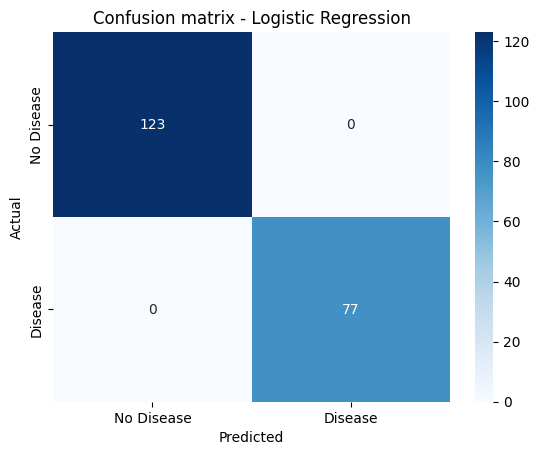

In [43]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test_dt,y_pred_dt)
plt.Figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=['No Disease','Disease'],yticklabels=['No Disease','Disease'])
plt.title('Confusion matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

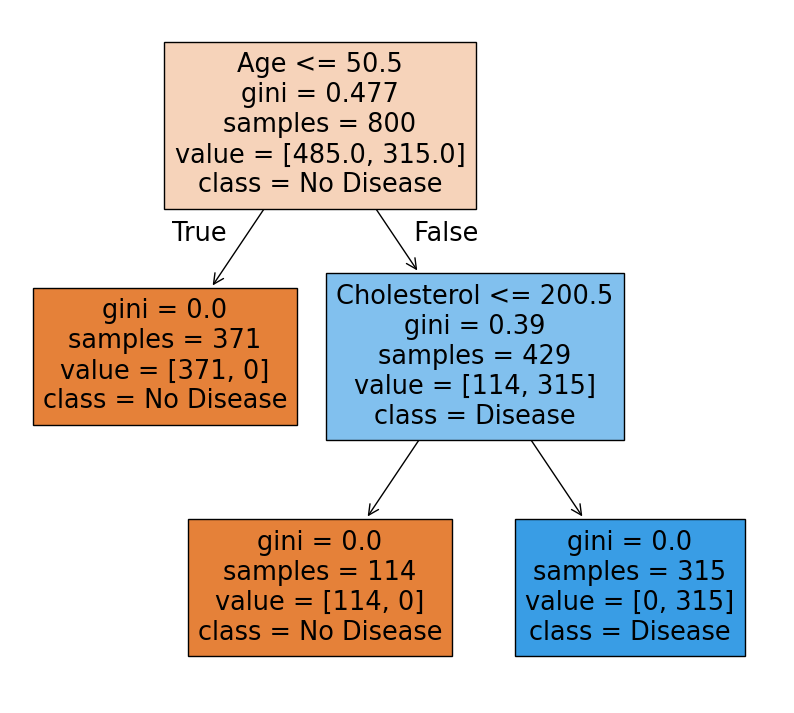

In [44]:
from sklearn import tree
import matplotlib.pyplot as plt
plt.figure(figsize=(10,9))
tree.plot_tree(dt_model,filled=True,feature_names=x_dt.columns,class_names=["No Disease","Disease"])
plt.show()


Part 4.2: Decision Tree After Encoding categrical columns

In [45]:
# Implementation of Decision Tree After Encoding
x_dtr=df.drop('Heart Disease',axis=1)
y_dtr=df['Heart Disease']
from sklearn.model_selection import train_test_split
x_train_dtr,x_test_dtr,y_train_dtr,y_test_dtr=train_test_split(x_dtr,y_dtr,test_size=0.2,random_state=2)
# creating model object
model_dtr=DecisionTreeClassifier()

# traning model on training data
model_dtr.fit(x_train_dtr,y_train_dtr)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [46]:
# predicting values
y_pred_dtr=model_dtr.predict(x_test_dtr)

# comparing actual values and predicted values
print("actual values:",y_test_dtr.values[:10])
print('predicted values:',y_pred_dtr[:10])

actual values: [1 0 0 0 0 1 0 1 0 0]
predicted values: [1 0 0 0 0 1 0 1 0 0]


In [47]:
# Evaluation Metrics
print('Accuracy:',accuracy_score(y_test_dtr,y_pred_dtr))
print('Precision:',precision_score(y_test_dtr,y_pred_dtr))
print('Recall:',recall_score(y_test_dtr,y_pred_dtr))
print('F1 score:',f1_score(y_test_dtr,y_pred_dtr))

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 score: 1.0


In [48]:
# Training accuracy
train_pred=model_dtr.predict(x_train_dtr)
print('Training Accuracy:',accuracy_score(y_train_dtr,train_pred))

Training Accuracy: 1.0


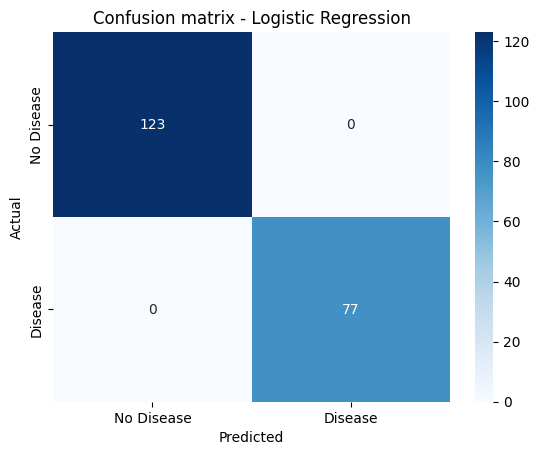

In [49]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test_dtr,y_pred_dtr)
plt.Figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=['No Disease','Disease'],yticklabels=['No Disease','Disease'])
plt.title('Confusion matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Part 5: Random Forest 

In [50]:
# implementing Rando Forest
from sklearn.ensemble import RandomForestClassifier

x_rf=df.drop('Heart Disease',axis=1)
y_rf=df['Heart Disease']

# splitting data into training and testing data
x_train_rf,x_test_rf,y_train_rf,y_test_rf=train_test_split(x_rf,y_rf,test_size=0.2,random_state=42)


In [51]:
# creating model object
model_rf=RandomForestClassifier(n_estimators=100)

# training model
model_rf.fit(x_train_rf,y_train_rf)

# making predictions
y_pred_rf=model_rf.predict(x_test_rf)

In [52]:
# Actual values vs Predicted values comparison
print("Actual values:",y_test_rf.values[:10])
print('Predicted values:',y_pred_rf[:10])

Actual values: [1 0 0 0 1 0 0 0 1 0]
Predicted values: [1 0 0 0 1 0 0 0 1 0]


In [53]:
# Evaluation Metrics
print('Accuracy:',accuracy_score(y_test_rf,y_pred_rf))
print('Precision:',precision_score(y_test_rf,y_pred_rf))
print('Recall:',recall_score(y_test_rf,y_pred_rf))
print('F1 score:',f1_score(y_test_rf,y_pred_rf))

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 score: 1.0


In [54]:
# calculating training accuracy
y_trainPred_rf=model_rf.predict(x_train_rf)
print('Training Accuracy:',accuracy_score(y_train_rf,y_trainPred_rf))

Training Accuracy: 1.0


In [55]:
# accuracy invstigation
corr=df.corr(numeric_only=True)
print(corr['Heart Disease'].sort_values(ascending=False))

Heart Disease                       1.000000
Age                                 0.646871
Cholesterol                         0.365041
Alcohol Intake                      0.061400
Smoking_Never                       0.045485
Smoking_Current                     0.044615
Family History                      0.030283
Gender                              0.029399
Chest Pain Type_Asymptomatic        0.022691
Chest Pain Type_Atypical Angina     0.016970
Diabetes                            0.016552
Heart Rate                          0.013209
Chest Pain Type_Typical Angina      0.009461
Stress Level                        0.007071
Blood Pressure                      0.006900
Exercise Induced Angina             0.004005
Blood Sugar                        -0.013004
Exercise Hours                     -0.014226
Obesity                            -0.018878
Chest Pain Type_Non-anginal Pain   -0.048587
Smoking_Former                     -0.090858
Name: Heart Disease, dtype: float64


Part 6: K-Nearest Neighbours

In [56]:
x_knn=df.drop('Heart Disease',axis=1)
y_knn=df['Heart Disease']

# splitting data into training and testing data
x_train_knn,x_test_knn,y_train_knn,y_test_knn=train_test_split(x_knn,y_knn,test_size=0.2,random_state=42)

In [57]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_knnScaled=scaler.fit_transform(x_train_knn)
x_test_knnScaled=scaler.transform(x_test_knn)

In [58]:
from sklearn.neighbors import KNeighborsClassifier
model_knn=KNeighborsClassifier(n_neighbors=15)

# training model
model_knn.fit(x_train_knnScaled,y_train_knn)

# making predictions
y_pred_knn=model_knn.predict(x_test_knnScaled)



In [59]:
# Evaluation Metrics
print('Accuracy:',accuracy_score(y_test_knn,y_pred_knn))
print('Precision:',precision_score(y_test_knn,y_pred_knn))
print('Recall:',recall_score(y_test_knn,y_pred_knn))
print('F1 score:',f1_score(y_test_knn,y_pred_knn))

Accuracy: 0.725
Precision: 0.7014925373134329
Recall: 0.573170731707317
F1 score: 0.6308724832214765


In [60]:
# calculating training accuracy
y_trainPred_knn=model_rf.predict(x_train_knnScaled)
print('Training Accuracy:',accuracy_score(y_train_knn,y_trainPred_knn))

Training Accuracy: 0.6125


C:\Users\abbas\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Part 7.1: Support Vector Machine

In [84]:
x_svm=df.drop('Heart Disease',axis=1)
y_svm=df['Heart Disease']

# splitting data into training and testing data
x_train_svm,x_test_svm,y_train_svm,y_test_svm=train_test_split(x_svm,y_svm,test_size=0.2,random_state=42)

In [85]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_SvmScaled=scaler.fit_transform(x_train_svm)
x_test_SvmScaled=scaler.transform(x_test_svm)

In [86]:
# implementation of SVM Linear
from sklearn.svm import SVC
model_svm=SVC(kernel='linear') # three types of svm kernel:linear,poly,rbf

# Training svm model
model_svm.fit(x_train_SvmScaled,y_train_svm)

# making predictions
y_pred_svm=model_svm.predict(x_test_SvmScaled)


In [87]:
# Evaluation Metrics
print('Accuracy:',accuracy_score(y_test_svm,y_pred_svm))
print('Precision:',precision_score(y_test_svm,y_pred_svm))
print('Recall:',recall_score(y_test_svm,y_pred_svm))
print('F1 score:',f1_score(y_test_svm,y_pred_svm))

Accuracy: 0.86
Precision: 0.8375
Recall: 0.8170731707317073
F1 score: 0.8271604938271605


In [88]:
# calculating training accuracy
y_trainPred_svm=model_svm.predict(x_train_SvmScaled)
print('Training Accuracy:',accuracy_score(y_train_svm,y_trainPred_svm))

Training Accuracy: 0.87375


Part 7.2:  SVM polynimial

In [89]:
# implementation of SVM Linear
from sklearn.svm import SVC
model_svm=SVC(kernel='poly') 

# Training svm model
model_svm.fit(x_train_SvmScaled,y_train_svm)

# making predictions
y_pred_svm=model_svm.predict(x_test_SvmScaled)

In [90]:
# Evaluation Metrics
print('Accuracy:',accuracy_score(y_test_svm,y_pred_svm))
print('Precision:',precision_score(y_test_svm,y_pred_svm))
print('Recall:',recall_score(y_test_svm,y_pred_svm))
print('F1 score:',f1_score(y_test_svm,y_pred_svm))

Accuracy: 0.8
Precision: 0.7916666666666666
Recall: 0.6951219512195121
F1 score: 0.7402597402597403


In [91]:
# calculating training accuracy
y_trainPred_svm=model_svm.predict(x_train_SvmScaled)
print('Training Accuracy:',accuracy_score(y_train_svm,y_trainPred_svm))

Training Accuracy: 0.95875


Part 7.3: SVM RBF

In [92]:
# implementation of SVM Linear
from sklearn.svm import SVC
model_svm=SVC(kernel='rbf') 

# Training svm model
model_svm.fit(x_train_SvmScaled,y_train_svm)

# making predictions
y_pred_svm=model_svm.predict(x_test_SvmScaled)

In [93]:
# Evaluation Metrics
print('Accuracy:',accuracy_score(y_test_svm,y_pred_svm))
print('Precision:',precision_score(y_test_svm,y_pred_svm))
print('Recall:',recall_score(y_test_svm,y_pred_svm))
print('F1 score:',f1_score(y_test_svm,y_pred_svm))

Accuracy: 0.865
Precision: 0.8666666666666667
Recall: 0.7926829268292683
F1 score: 0.8280254777070064


In [94]:
# calculating training accuracy
y_trainPred_svm=model_svm.predict(x_train_SvmScaled)
print('Training Accuracy:',accuracy_score(y_train_svm,y_trainPred_svm))

Training Accuracy: 0.9675


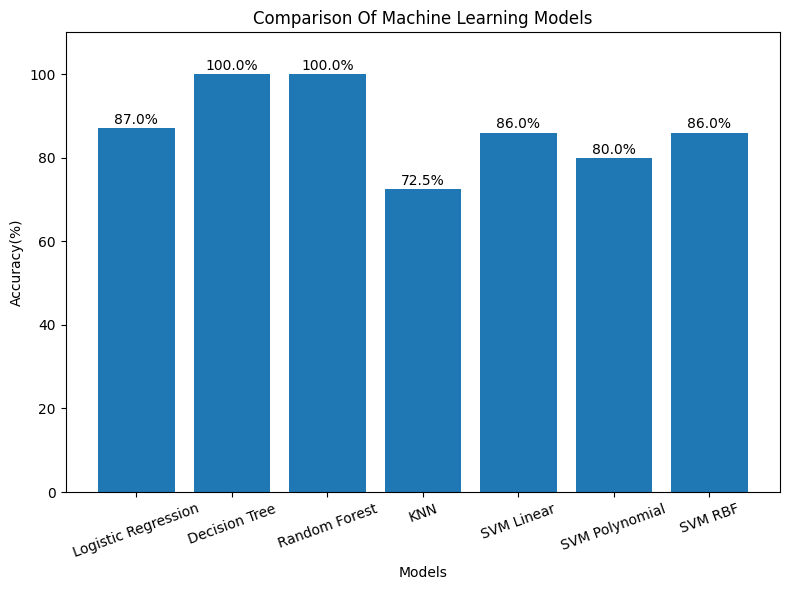

In [100]:
# Compaing Models Accuracies
models=['Logistic Regression','Decision Tree','Random Forest','KNN','SVM Linear','SVM Polynomial','SVM RBF']
accuracies=[87,100,100,72.5,86,80,86]
plt.figure(figsize=(8,6))
bars=plt.bar(models,accuracies)
plt.title('Comparison Of Machine Learning Models')
plt.xlabel('Models')
plt.ylabel('Accuracy(%)')
plt.ylim(0,110)
for bar in bars:
    height=bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2,height+1,f"{height}%",ha='center')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

